# Health and Lifestyle Data Analysis

## Project Objective

The objective of this project is to analyze health and lifestyle data to explore patterns and relationships between sleep habits, physical fitness, mental well-being, and overall health.

The analysis also examines whether early waking habits are associated with differences in sleep quality and overall health.

## Import Libraries 

In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size']= 12
plt.rcParams['axes.labelsize'] = 10 
plt.rcParams['axes.titlesize'] = 12 
sns.set_style('whitegrid')


PALETTE = {'Yes': "#00FF00",  'No': "#FF0000"}


## Load Dataset

In [2]:
df = pd.read_csv("early_wakeup_health_dataset.csv")
# for full view of columns use this :-
pd.set_option("display.max_columns" , None)
df.head(10)

,Person_ID,Age,Gender,Height_cm,Weight_kg,BMI,Country,Occupation,Marital_Status,Wake_Up_Time,Sleep_Time,Sleep_Duration_Hours,Sleep_Quality_Score,Number_of_Night_Awakenings,Weekend_Sleep_Difference_Hours,Nap_Frequency_Per_Week,Screen_Time_Before_Bed_Hours,Exercise_Frequency_Per_Week,Exercise_Duration_Minutes,Exercise_Type,Daily_Steps,Morning_Workout,Workout_Intensity,Gym_Member,Daily_Calorie_Intake,Water_Intake_Liters,Fruit_Intake_Per_Day,Vegetable_Intake_Per_Day,Protein_Intake_Grams,Sugary_Drinks_Per_Week,Fast_Food_Meals_Per_Week,Breakfast_Regularity_Score,Smoking_Status,Alcohol_Consumption,Stress_Level,Working_Hours_Per_Day,Sitting_Hours_Per_Day,Outdoor_Time_Hours,Social_Interaction_Score,Meditation_Practice,Resting_Heart_Rate,Systolic_BP,Diastolic_BP,Cholesterol_Level,Blood_Sugar_Level,Energy_Level_Score,Fatigue_Level_Score,Immune_Health_Score,Mood_Score,Anxiety_Score,Depression_Risk_Score,Productivity_Score,Focus_Concentration_Score,Life_Satisfaction_Score,Obesity_Risk,Hypertension_Risk,Diabetes_Risk,Cardiovascular_Risk,Sleep_Disorder_Risk,Health_Score,Fitness_Level,Healthy_Aging_Score,Wellness_Category,Early_Waker
0,P00001,76,Female,158.8,62.1,24.63,Italy,Entrepreneur,Widowed,08:59,01:29,7.51,5.9,2,1.28,5,1.65,4,47,Weight Training,10863,No,Low,Yes,2034,3.35,2,4,80.4,0,0,7.9,Former,Moderate,2.1,8.3,7.9,3.23,6.8,Yes,76,145,86,194.0,120.3,9.2,2.0,7.0,8.1,4.0,1.7,6.2,7.4,8.0,Low,High,Medium,Medium,Low,87.3,Excellent,81.8,Excellent,No
1,P00002,49,Female,160.9,68.5,26.45,USA,Freelancer,Single,06:35,02:25,4.16,5.5,0,0.24,1,1.63,4,43,Walking,5861,Yes,Moderate,No,2236,2.46,2,4,100.9,7,5,8.1,Current,NaN,2.4,3.7,4.8,1.89,5.1,No,69,135,86,221.5,114.0,9.1,1.0,4.1,7.7,5.8,1.5,8.2,5.5,9.3,Medium,Medium,Medium,Low,Medium,72.0,Good,75.2,Good,No
2,P00003,51,Female,151.9,54.8,23.77,Mexico,Nurse,Single,07:31,02:24,5.12,8.4,0,1.54,4,0.04,0,94,NaN,2172,No,NaN,Yes,1884,1.60,3,4,42.7,6,4,8.0,Never,Light,2.9,7.6,7.4,1.08,6.7,No,66,139,96,204.1,113.1,7.1,2.8,5.9,6.5,5.7,1.5,7.6,6.6,7.1,Low,Medium,Medium,Low,Low,75.2,Good,77.1,Good,No
3,P00004,48,Male,167.6,81.3,28.93,Australia,Laborer,Single,08:36,01:19,7.29,4.6,1,0.37,1,2.56,6,39,Running,11437,Yes,Moderate,No,2192,2.67,7,5,106.9,3,0,6.8,Never,Light,4.6,8.4,7.1,4.06,6.4,No,66,136,96,227.0,95.1,9.0,2.6,9.5,6.3,5.4,1.7,7.9,6.5,8.6,Medium,Medium,Low,Low,Medium,82.7,Excellent,87.1,Excellent,No
4,P00005,68,Female,171.9,75.4,25.51,USA,Software Engineer,Married,07:07,01:20,5.79,6.1,1,1.81,2,1.18,0,55,NaN,2851,No,NaN,Yes,1466,2.27,4,6,113.9,0,6,6.9,Former,NaN,5.1,3.2,4.0,0.23,2.6,No,73,146,92,232.0,104.8,6.9,3.6,7.8,4.4,6.6,3.1,4.4,6.1,6.7,Medium,High,Medium,Medium,Low,62.7,Average,58.1,Average,No
5,P00006,79,Male,166.2,60.5,21.90,India,Accountant,Married,07:50,01:05,6.76,4.3,1,1.30,0,0.25,0,48,NaN,4832,No,NaN,Yes,1711,1.30,3,3,91.4,0,7,6.8,Never,NaN,4.6,4.4,4.6,0.74,3.8,No,72,168,109,264.1,104.4,4.5,6.3,6.1,5.6,5.8,2.8,6.8,6.4,6.7,Low,High,Medium,High,Medium,60.6,Average,52.0,Average,No
6,P00007,74,Male,169.9,55.0,19.06,Canada,Software Engineer,Single,06:49,23:48,7.01,5.1,1,-0.35,0,1.37,5,100,Running,12234,No,High,No,2316,3.28,0,5,112.0,3,8,6.4,Current,Light,8.8,9.8,7.3,5.94,5.1,Yes,66,154,103,201.7,103.4,7.2,4.2,5.1,5.3,6.7,3.1,5.3,6.4,6.5,Low,High,Medium,Medium,Low,72.3,Good,66.7,Good,No
7,P00008,67,Female,160.8,82.5,31.91,Brazil,Retired,Single,06:11,00:30,5.68,4.6,1,0.50,1,0.29,3,63,Weight Training,3499,No,Moderate,No,2172,2.51,2,2,87.1,5,5,6.4,Never,Moderate,9.6,6.3,6.9,1.72,7.4,No,80,160,106,238.1,119.5,5.9,5.1,5.3,5.3,7.3,3.6,6.3,7.9,5.5,High,High,Medium,Medium,Medium,46.7,Average,39.6,Average,Yes
8,P00009,22,Male,190.8,65.1,17.88,UK,Software Engineer,Single,06:54,00:22,6.53,5.5,1,1.45,4,0.42,3,50,Cycling,8124,No,Moderate,No,1670,1.74,5,3,109.8,5,3,4.8,Former,Light,6.6,5.0,5.5,2.36,3.8,No,72,125,80,185.7,83.2,6.2,3.3,7.9,6.4,6.5,4.0,7.3,6.4,7.1,Low,Low,Low,Low,Low,78.8,Good,90.2,Good,No
9,P00010,22,Male,177.9,90.7,28.67,Italy,Software Engineer,Single,07:06,00:41,6.42,4.2,0,0.97,2,0.19,3,59,Yoga,6718

## Dataset Overview
The dataset contains 10,000 records and 65 features covering demographics, sleep habits, physical activity, diet, mental well-being, and health indicators.

In [3]:
df.shape

(10000, 64)

In [4]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 64 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Person_ID                       10000 non-null  object 
 1   Age                             10000 non-null  int64  
 2   Gender                          10000 non-null  object 
 3   Height_cm                       10000 non-null  float64
 4   Weight_kg                       10000 non-null  float64
 5   BMI                             10000 non-null  float64
 6   Country                         10000 non-null  object 
 7   Occupation                      10000 non-null  object 
 8   Marital_Status                  10000 non-null  object 
 9   Wake_Up_Time                    10000 non-null  object 
 10  Sleep_Time                      10000 non-null  object 
 11  Sleep_Duration_Hours            10000 non-null  float64
 12  Sleep_Quality_Score             1

In [5]:
display(df.describe().T) # here in we use T for table view instead of df.describe()

,count,mean,std,min,25%,50%,75%,max
Age,10000.0,44.666700,17.517200,18.0,29.7500,43.00,58.0000,80.00
Height_cm,10000.0,168.649160,9.876706,145.0,161.4000,168.20,175.5000,205.50
Weight_kg,10000.0,73.107340,16.291950,33.6,61.3000,72.00,83.5000,166.60
BMI,10000.0,25.626963,4.870317,16.0,22.1700,25.58,28.8625,44.56
Sleep_Duration_Hours,10000.0,7.229332,1.118486,4.0,6.4700,7.23,7.9800,10.00
Sleep_Quality_Score,10000.0,6.020190,1.585689,1.0,4.9000,6.00,7.1000,9.80
Number_of_Night_Awakenings,10000.0,0.839100,0.936215,0.0,0.0000,1.00,1.0000,6.00
Weekend_Sleep_Difference_Hours,10000.0,1.027020,0.787941,-1.0,0.4975,1.03,1.5600,3.81
Nap_Frequency_Per_Week,10000.0,2.120800,1.905196,0.0,0.7500,2.00,3.0000,7.00
Screen_Time_Before_Bed_Hours,10000.0,1.144012,1.044281,0.0,0.3300,0.81,1.6500,4.00


## Data Quality Check

In [6]:
df.isna().sum().sort_values(ascending=False).head(5) # Here we use sort_values because it give most missinng value on top

Alcohol_Consumption    3014
Workout_Intensity       824
Exercise_Type           824
Person_ID                 0
Weight_kg                 0
dtype: int64

## Duplicate Records


In [7]:
df.duplicated().sum()


np.int64(0)

## Data Cleaning

The dataset was checked for missing values, duplicate records, and data type inconsistencies before performing exploratory analysis.

## Univariate Analysis

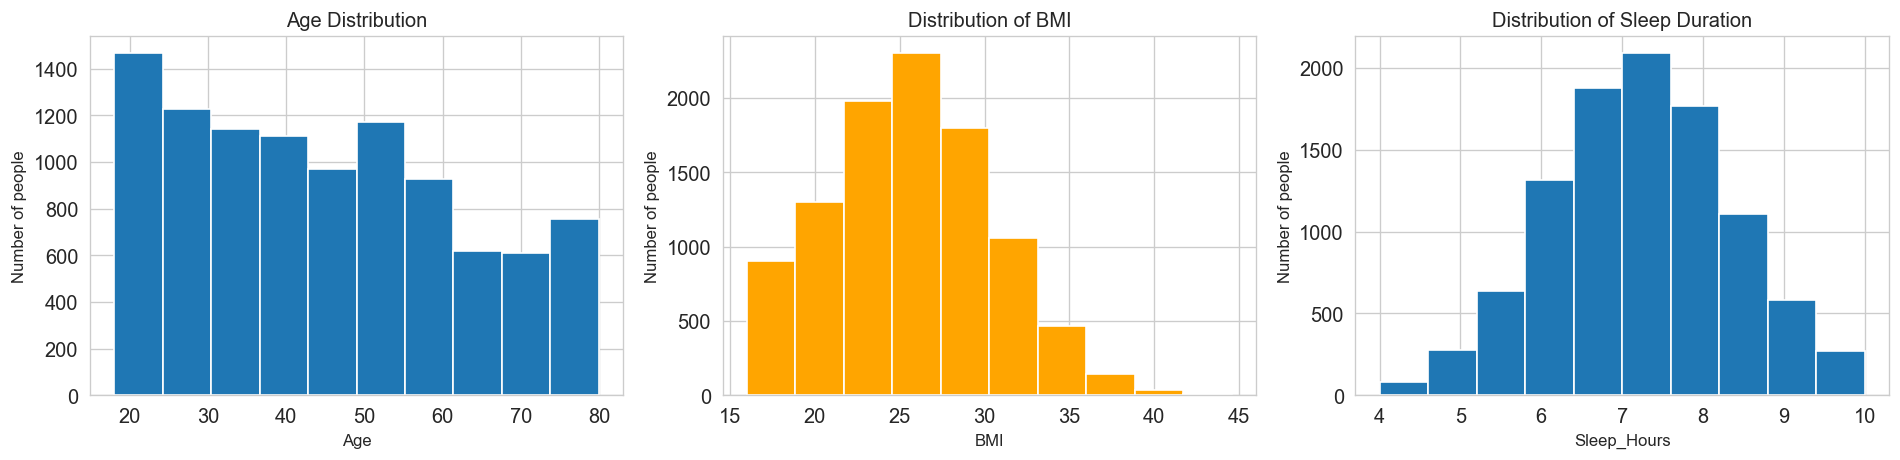

In [8]:
fig,axes = plt.subplots(1,3 , figsize=(16,4))

#1 Age Distribution
age = df['Age'].hist(ax=axes[0])
axes[0].set_title('Age Distribution')
axes[0].set_xlabel("Age")
axes[0].set_ylabel("Number of people")

# This  chart show maximum number of people is below 50

# 2 BMI
BMI = df['BMI'].hist(ax=axes[1] , color='orange')
axes[1].set_title("Distribution of BMI")
axes[1].set_xlabel("BMI")
axes[1].set_ylabel("Number of people")


# 3 sleep duration
df["Sleep_Duration_Hours"].hist(ax=axes[2])
axes[2].set_title("Distribution of Sleep Duration")
axes[2].set_xlabel("Sleep_Hours")
axes[2].set_ylabel("Number of people")
plt.tight_layout()
plt.show()

## Early Waker Analysis

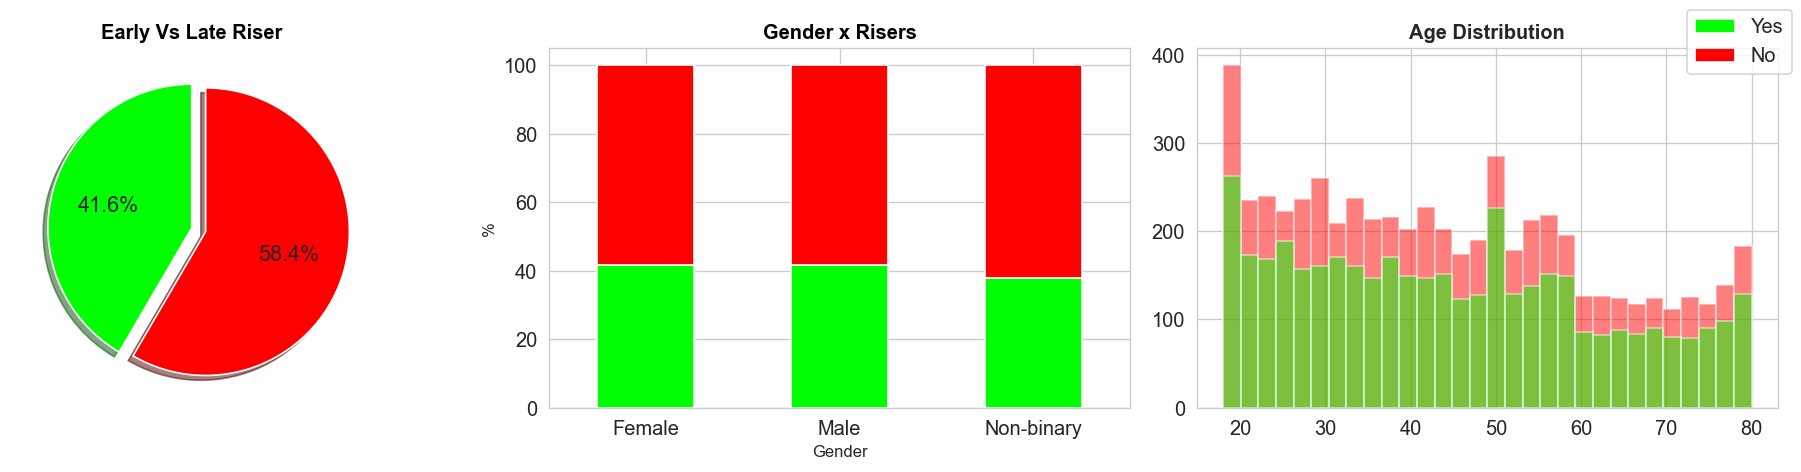

In [9]:
# 1. Early_Risers vs Late_Risers

fig,axes=plt.subplots(1,3 ,figsize=(16,4))
counts = df['Early_Waker'].value_counts().reindex(['Yes','No'])
counts
explode= [0,0.1]

axes[0].pie( counts , autopct='%1.1f%%',
             colors= [PALETTE[c] for c in counts.index],
             startangle = 90,
              shadow = True,
             
              explode = explode,
              textprops={'fontsize':13}) # here we use textpros because fontsize is not applied without it inside pie
axes[0].set_title("Early Vs Late Riser", fontweight ='bold' , color= '#000000') 


# 2.  Gender breakdown
ct = pd.crosstab(df['Gender'],df["Early_Waker"] , normalize= 'index')*100  # here normaliize = index give us percentage of each row
ct =ct[['Yes','No']]
ct.plot(kind='bar',stacked=True,ax=axes[1],color =[ PALETTE[c] for c in ct.columns], )
axes[1].set_title('Gender x Risers', color='#000000',fontweight='bold')
axes[1].set_ylabel('%')
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend_.remove()

# 3. Age 
for label ,grp in df.groupby("Early_Waker"):
    axes[2].hist(grp['Age'], bins=30, label=label, alpha=0.5,  color=PALETTE[label], edgecolor='white')
axes[2].set_title('Age Distribution', fontweight='bold')

fig.legend(['Yes','No'])
plt.tight_layout()
plt.show()


## Bivariate and Relationship Analysis

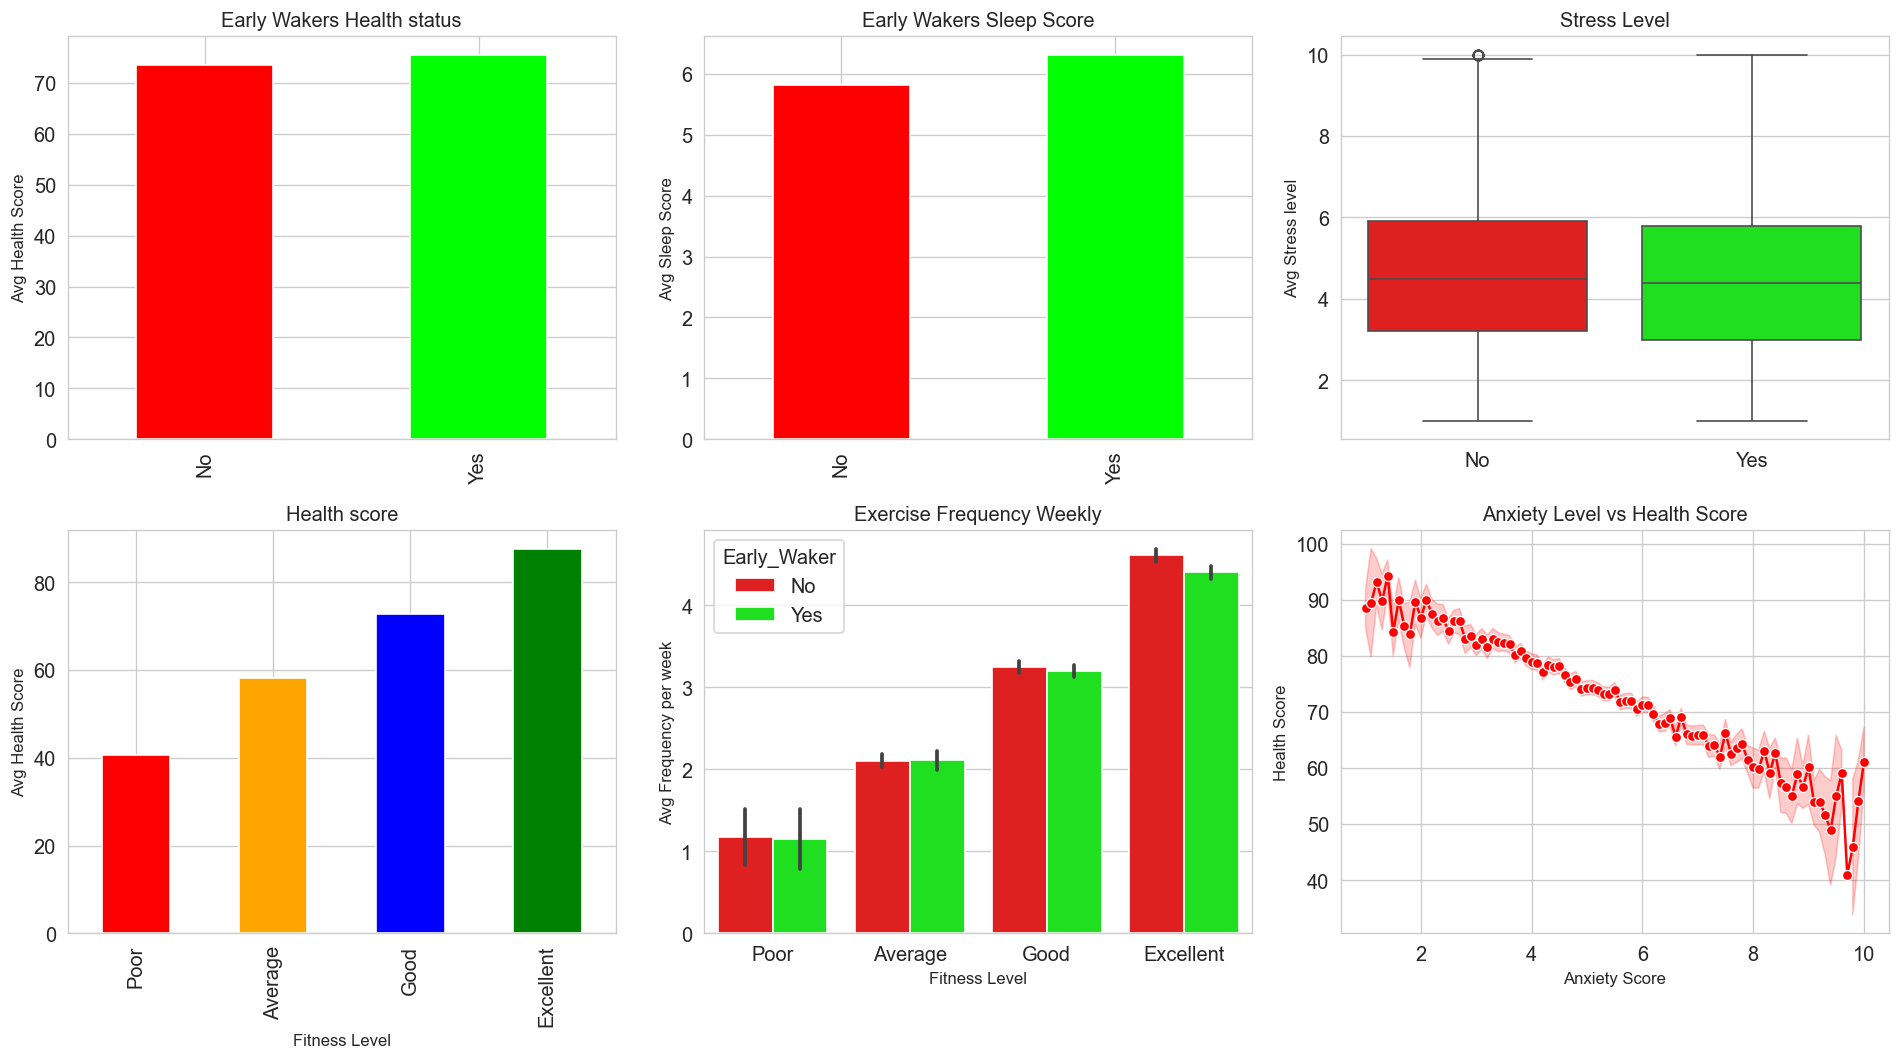

In [10]:
fig,axes =plt.subplots(2,3 , figsize=(16,9))

# 1 Early_wakers Health score
df.groupby("Early_Waker")["Health_Score"].mean().plot(kind="bar" ,ax=axes[0,0],color=[PALETTE["No"], PALETTE["Yes"]])
axes[0,0].set_title("Early Wakers Health status")
axes[0,0].set_xlabel("")
axes[0,0].set_ylabel("Avg Health Score")

# 2 Early Waker Sleep Quality
df.groupby("Early_Waker")["Sleep_Quality_Score"].mean().plot(kind="bar" , ax= axes[0,1],color=[PALETTE["No"], PALETTE["Yes"]] )

axes[0,1].set_title("Early Wakers Sleep Score")
axes[0,1].set_xlabel("")
axes[0,1].set_ylabel("Avg Sleep Score")

# 3 Stress Level
                     # here in seaborn we dont need to  use it automaticaly calculate  (df.groupby("Early_Waker")["Stress_Level"].mean())
sns.boxplot(
    data=df,
    x="Early_Waker",
    y="Stress_Level",
    hue="Early_Waker",
    palette=PALETTE,
    ax=axes[0,2]
)
axes[0,2].set_title("Stress Level")
axes[0,2].set_xlabel("")
axes[0,2].set_ylabel("Avg Stress level")

# 4 Health score by Fitness level
order = ["Poor", "Average", "Good", "Excellent"]
df.groupby("Fitness_Level")["Health_Score"].mean().reindex(order).plot(kind="bar" ,ax=axes[1,0],color=["red", "orange", "blue", "green"])
axes[1,0].set_title('Health score')
axes[1,0].set_xlabel("Fitness Level")
axes[1,0].set_ylabel("Avg Health Score")

# 5 Exercise Frequency
order = ["Poor", "Average", "Good", "Excellent"]
sns.barplot(
    data=df,
    x="Fitness_Level",
    y="Exercise_Frequency_Per_Week",
    order=order,
    ax=axes[1,1],
    hue="Early_Waker",
    palette=PALETTE
)
axes[1,1].set_title("Exercise Frequency Weekly"),
axes[1,1].set_xlabel("Fitness Level"),
axes[1,1].set_ylabel("Avg Frequency per week")

                                                     #  This is use for hide the chart like 6th one    axes[1,2].set_visible(False)

# 6.  Anxiety Level vs Health Score
sns.lineplot(
    data=df,
    x="Anxiety_Score",
    y="Health_Score",
    marker="o" ,
    ax=axes[1,2],
    color='red'
    
)
axes[1,2].set_title("Anxiety Level vs Health Score"),
axes[1,2].set_xlabel("Anxiety Score"),
axes[1,2].set_ylabel("Health Score")
plt.tight_layout()
plt.show()

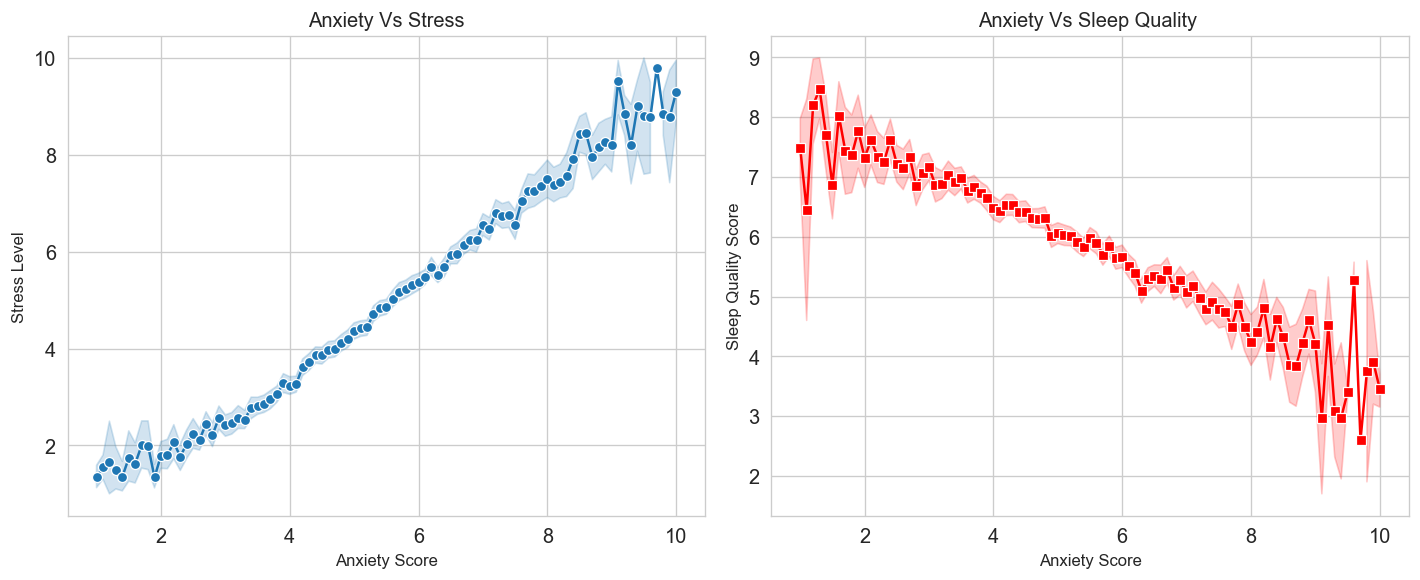

In [11]:
fig,axes =plt.subplots(1,2 , figsize=(12,5))
# 1 Anxiety vs Stress
sns.lineplot(
       data=df,
       x="Anxiety_Score",
       y="Stress_Level",
       ax=axes[0],
       marker='o'
    
)
axes[0].set_title('Anxiety Vs Stress'),
axes[0].set_xlabel('Anxiety Score'),
axes[0].set_ylabel('Stress Level')

# 2 Anxiety VS Sleep Quality
sns.lineplot(
       data=df,
       x="Anxiety_Score",
       y="Sleep_Quality_Score",
       ax=axes[1],
       marker='s',
       color='red'
)
axes[1].set_title('Anxiety Vs Sleep Quality '),
axes[1].set_xlabel('Anxiety Score'),
axes[1].set_ylabel('Sleep Quality Score')
plt.tight_layout()
plt.show()

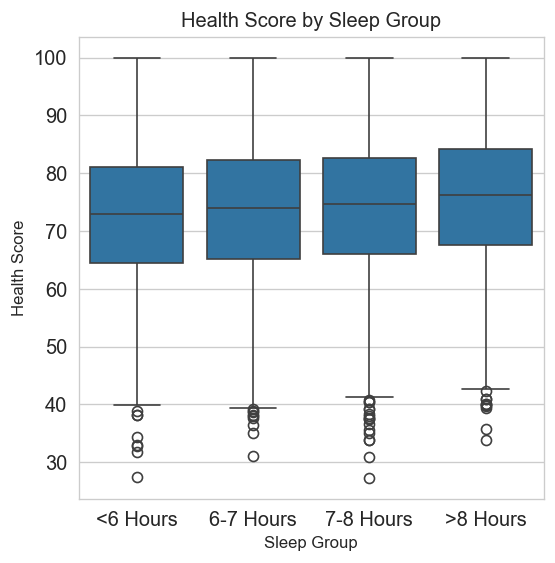

In [12]:
# here we make sleep group new coloumn becuase in scatter plot it seem chaotic so we using pd.cut
bins =[0,6,7,8,24]
labels = ['<6 Hours' ,'6-7 Hours' , '7-8 Hours' , '>8 Hours']
df['sleep_group'] = pd.cut( df["Sleep_Duration_Hours"],
                           bins=bins,
                           labels=labels
)
# check the created group work perfectly or not
df[["Sleep_Duration_Hours" , "sleep_group"]].head(5)
plt.figure(figsize=(5,5))
sns.boxplot(data=df, x='sleep_group', y='Health_Score')

plt.title('Health Score by Sleep Group')
plt.xlabel('Sleep Group')
plt.ylabel('Health Score')
plt.show()

###  Age Vs BMI Analysis

In [13]:
df[['Age','BMI']].corr()

,Age,BMI
Age,1.000000,0.092279
BMI,0.092279,1.000000


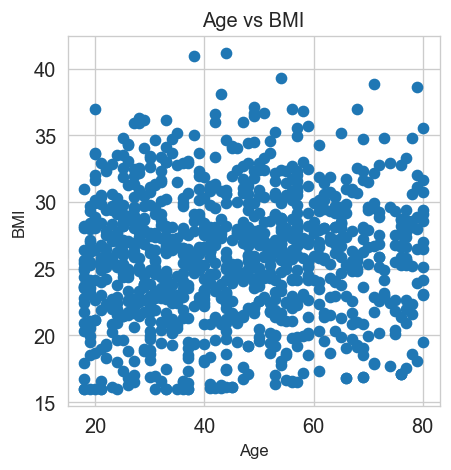

In [14]:

sample = df.sample(1000 , random_state=40)
plt.figure(figsize=(4,4)),
plt.scatter( sample['Age'] , sample['BMI'] ),
plt.title("Age vs BMI"),
plt.xlabel("Age"),
plt.ylabel("BMI")
plt.show()
# Here we use a sample of random values otherwise it would be chaotic  

## Additional Variables Explored

<Axes: xlabel='Occupation'>

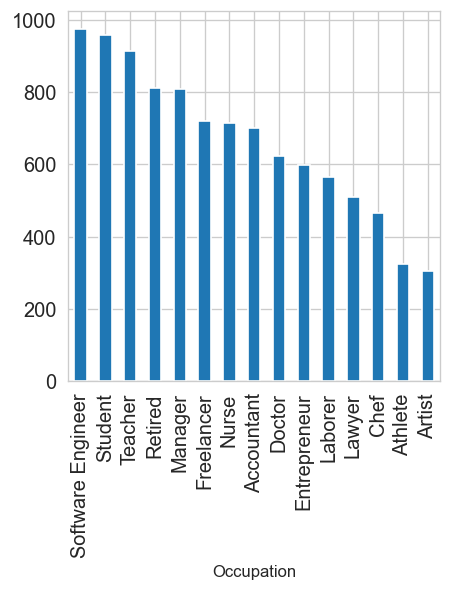

In [15]:
df["Occupation"].value_counts().plot(kind="bar",figsize=(4,4))

<Axes: xlabel='Occupation'>

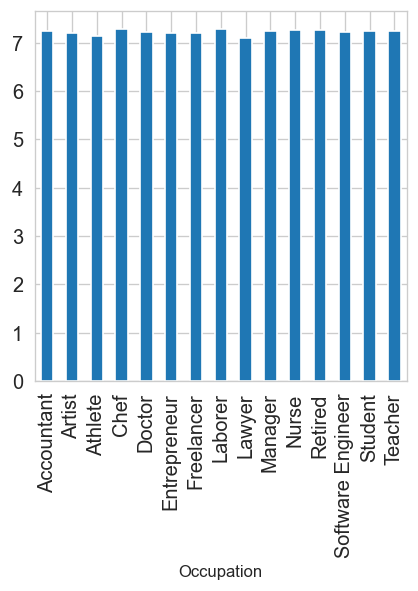

In [16]:
df.groupby("Occupation")["Sleep_Duration_Hours"].mean().plot(kind='bar',figsize=(4,4))

In [17]:
df['Country'].value_counts()

Country
USA            1468
India          1206
UK              798
Canada          763
Japan           667
Germany         623
Pakistan        598
Australia       574
Brazil          572
Mexico          491
France          478
Nigeria         470
South Korea     468
Spain           427
Italy           397
Name: count, dtype: int64

In [18]:
df.groupby("Country")["Health_Score"].mean()


Country
Australia      74.165331
Brazil         75.160839
Canada         74.053473
France         74.239958
Germany        74.029213
India          73.774627
Italy          73.875567
Japan          74.196402
Mexico         74.156212
Nigeria        74.353404
Pakistan       74.267391
South Korea    73.341667
Spain          75.101405
UK             73.715789
USA            74.635627
Name: Health_Score, dtype: float64

## Correlation

### Heatmap

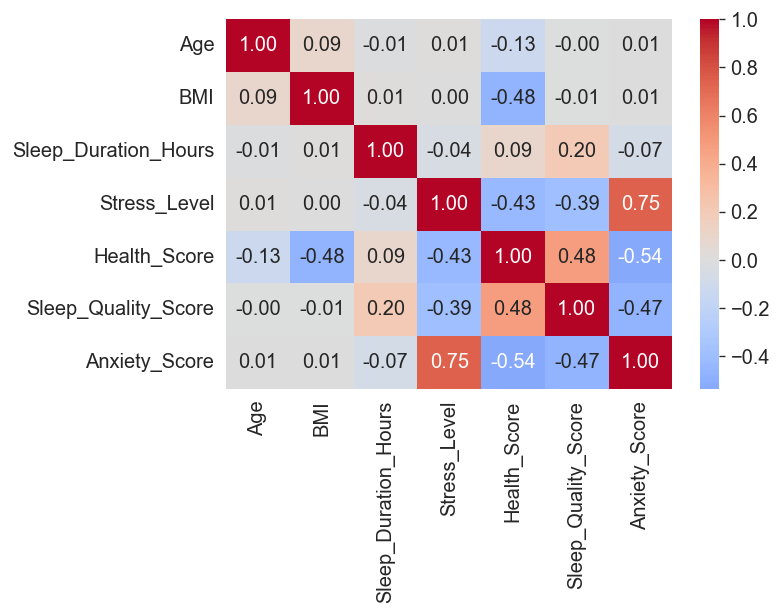

In [19]:
cols = [
    'Age',
    'BMI',
    'Sleep_Duration_Hours',
    'Stress_Level',
    'Health_Score',
    "Sleep_Quality_Score",
    "Anxiety_Score"
    
]
corr = df[cols].corr(numeric_only=True)
plt.figure(figsize=(6, 4))
sns.heatmap(corr,
            cmap='coolwarm',
            center=0,
            annot=True,
            fmt=".2f"
           
           )
plt.show()

## Stress correlation with Sleep 

In [20]:
df[['Stress_Level','Sleep_Quality_Score']].corr()

,Stress_Level,Sleep_Quality_Score
Stress_Level,1.000000,-0.394299
Sleep_Quality_Score,-0.394299,1.000000


## Key Findings
1. Stress level and Sleep quality  showed a moderate negative correlation of approximately -0.39, indicating that higher stress levels tend to be associated with lower sleep quality.
2. Age and BMI showed a very weak positive correlation, suggesting little linear relationship between them in this dataset.
3. Early wakers have a slightly higher average Health Score (about 2 points) than non-early wakers. The difference exists but is relatively small.
4. Higher anxiety levels are associated with higher average stress levels.
5. Higher anxiety levels were associated with lower average Health Scores.
6. Individuals with excellent fitness levels had the highest average health scores.
7. Exercise frequency tended to be higher among individuals with better fitness levels.

## Conclusion

This analysis explored how different lifestyle and well-being factors are related to overall health. The results showed notable patterns between anxiety, stress, and sleep quality, with higher anxiety being associated with increased stress and poorer sleep quality. Fitness and exercise patterns also showed positive associations with health-related outcomes.

The comparison between early and non-early wakers showed only small differences in overall health, suggesting that waking early alone may not be strongly associated with better health. Overall, the analysis highlights that health is connected to multiple lifestyle and mental well-being factors rather than a single habit.